In [2]:
import pyzed.sl as sl
import cv2
import numpy as np
import threading
import time
import signal

import time
import threading
import matplotlib.pyplot as plt

### Run cameras

In [3]:
zed_list = []
current_images = []
current_timestamps = []
thread_list = []
stop_signal = False

imgs = [[0],[0]]
# latest_images = []




def signal_handler(signal, frame):
    global stop_signal
    stop_signal=True
    time.sleep(0.5)
    exit()

def grab_run(index):
    global stop_signal
    global zed_list
    global current_timestamps
    global current_images
    global name_list
    global timestamps_and_images
    # global latest_images
    # for cam in zed_list:
    #     latest_images.append(sl.Mat())

    runtime = sl.RuntimeParameters()
    while not stop_signal:

        err = zed_list[index].grab(runtime)
        if err == sl.ERROR_CODE.SUCCESS:
            # latest_image = sl.Mat()
            zed_list[index].retrieve_image(current_images[index], sl.VIEW.LEFT)
            # zed_list[index].retrieve_image(latest_images[index], sl.VIEW.LEFT)
            # current_images = latest_images

            current_timestamp = zed_list[index].get_timestamp(sl.TIME_REFERENCE.CURRENT).data_ns #time of function call
            image_timestamp= zed_list[index].get_timestamp(sl.TIME_REFERENCE.IMAGE).data_ns # time of frame extraction 

            current_timestamps[index] = current_timestamp

            # timestamps_and_images[name_list[index]]['IMG'].append(latest_images[index])
            # timestamps_and_images[name_list[index]]['IMG'].append(current_images[index])
            timestamps_and_images[name_list[index]]['CURRENT_ts'].append(current_timestamp)
            timestamps_and_images[name_list[index]]['IMAGE_ts'].append(image_timestamp)
            timestamps_and_images[name_list[index]]['FPS'].append(zed_list[index].get_current_fps())
        barrier.wait()

        time.sleep(0.001) #0.1ms
    zed_list[index].close()

def main():
    global stop_signal
    global zed_list
    global current_images
    global current_timestamps
    global thread_list
    global name_list
    global barrier
    signal.signal(signal.SIGINT, signal_handler)
    # global latest_images

    global timestamps_and_images
    timestamps_and_images = {
    'ZED_43957242': {
        'CURRENT_ts': [],
        'IMAGE_ts': [],
        'IMG':[],
        'FPS':[]
    },
    'ZED_43916681': {
        'CURRENT_ts': [],
        'IMAGE_ts': [],
        'IMG':[],
        'FPS': []
    }
}

    print("Running...")
    init = sl.InitParameters()
    init.camera_resolution = sl.RESOLUTION.HD1080
    init.camera_fps = 60  # The framerate is lowered to avoid any USB3 bandwidth issues
    # init.async_image_retrieval = True


    #List and open cameras
    name_list = []
    last_ts_list = []
    cameras = sl.Camera.get_device_list()

    index = 0
    for cam in cameras:
        init.set_from_serial_number(cam.serial_number) # define input source
        name_list.append(f"ZED_{cam.serial_number}")
        print(f"Opening {name_list[index]}")
        zed_list.append(sl.Camera())
        current_images.append(sl.Mat())
        current_timestamps.append(0)
        last_ts_list.append(0)
        status = zed_list[index].open(init)
        if status != sl.ERROR_CODE.SUCCESS:
            print(repr(status))
            zed_list[index].close()
        index = index +1

    num_threads = len(zed_list)
    barrier = threading.Barrier(num_threads)

    #Start camera threads
    for index in range(0, len(zed_list)):
        if zed_list[index].is_opened():
            thread_list.append(threading.Thread(target=grab_run, args=(index,)))
            thread_list[index].start()
    

    #Display camera images
    key = ''
    while key != 113:  # for 'q' key
        for cam_index in range(0, len(zed_list)):
            if zed_list[cam_index].is_opened():
                # timestamps_and_images[name_list[index]]['IMG'].append(current_images[index])

                
                # if there is a new frame 
                if (current_timestamps[cam_index] >= last_ts_list[cam_index]):
                    img = current_images[cam_index].get_data()
                    imgs[cam_index].append(img)

                    img = cv2.circle(img,(960,540),10,(0,0,255),3)
                    
                    cv2.imshow(name_list[cam_index], cv2.resize(img,(800,600)))

                    # set the last timestamp for each cam to the CURRENT_ts one of each cam 
                    last_ts_list[cam_index] = current_timestamps[cam_index]

        key = cv2.waitKey(10)
    cv2.destroyAllWindows()

    #Stop the threads
    stop_signal = True
    for index in range(0, len(thread_list)):
        thread_list[index].join()

    print("\nFINISH")

if __name__ == "__main__":
    main()

Running...
[2025-02-13 14:17:18 UTC][ZED][INFO] Logging level INFO
[2025-02-13 14:17:18 UTC][ZED][INFO] Logging level INFO
Opening ZED_43957242
[2025-02-13 14:17:19 UTC][ZED][INFO] Logging level INFO
[2025-02-13 14:17:19 UTC][ZED][INFO] Logging level INFO
[2025-02-13 14:17:19 UTC][ZED][INFO] Logging level INFO
[2025-02-13 14:17:19 UTC][ZED][INFO] [Init]  Depth mode: PERFORMANCE
[ZED-X][Warning] Failed to connect to zed_x_daemon.
[2025-02-13 14:17:24 UTC][ZED][INFO] [Init]  Camera FW version: 2001
[2025-02-13 14:17:24 UTC][ZED][INFO] [Init]  Video mode: HD1080@60
[2025-02-13 14:17:24 UTC][ZED][INFO] [Init]  Serial Number: S/N 43957242
[2025-02-13 14:17:24 UTC][ZED][WARNING] [Init]  Self-calibration failed. Point the camera towards a more textured and brighter area. Avoid objects closer than 1 meter (Error code: 0x01) 
Opening ZED_43916681
[2025-02-13 14:17:25 UTC][ZED][INFO] Logging level INFO
[2025-02-13 14:17:25 UTC][ZED][INFO] Logging level INFO
[2025-02-13 14:17:25 UTC][ZED][INFO] L

In [5]:
(timestamps_and_images['ZED_43916681']['IMG'][51] == timestamps_and_images['ZED_43916681']['IMG'][0]).all()


False

In [12]:
print(timestamps_and_images.keys())
key = ''
count = 0
# for img in timestamps_and_images['ZED_43957242']['IMG']:
for img in imgs[0]:
    cv2.imshow('asdf', img)
    key = cv2.waitKey(30)
    count += 1 


cv2.destroyAllWindows()

print(count)



dict_keys(['ZED_43957242', 'ZED_43916681'])
41


### Plotting timestamps

In [5]:
## timestamps_and_images in ms for each camera
cam_1_current = np.array(timestamps_and_images['ZED_43957242']['CURRENT_ts'])/1000000
cam_2_current = np.array(timestamps_and_images['ZED_43916681']['CURRENT_ts'])/1000000

cam_1_img = np.array(timestamps_and_images['ZED_43957242']['IMAGE_ts'])/1000000
cam_2_img = np.array(timestamps_and_images['ZED_43916681']['IMAGE_ts'])/1000000

# print(timestamps_and_images.keys())
print(f'cam1 stamps: {cam_1_current.shape, cam_1_img.shape}')
print(f'cam2 stamps: {cam_2_current.shape, cam_2_img.shape}')

cam1 stamps: ((107,), (107,))
cam2 stamps: ((107,), (107,))


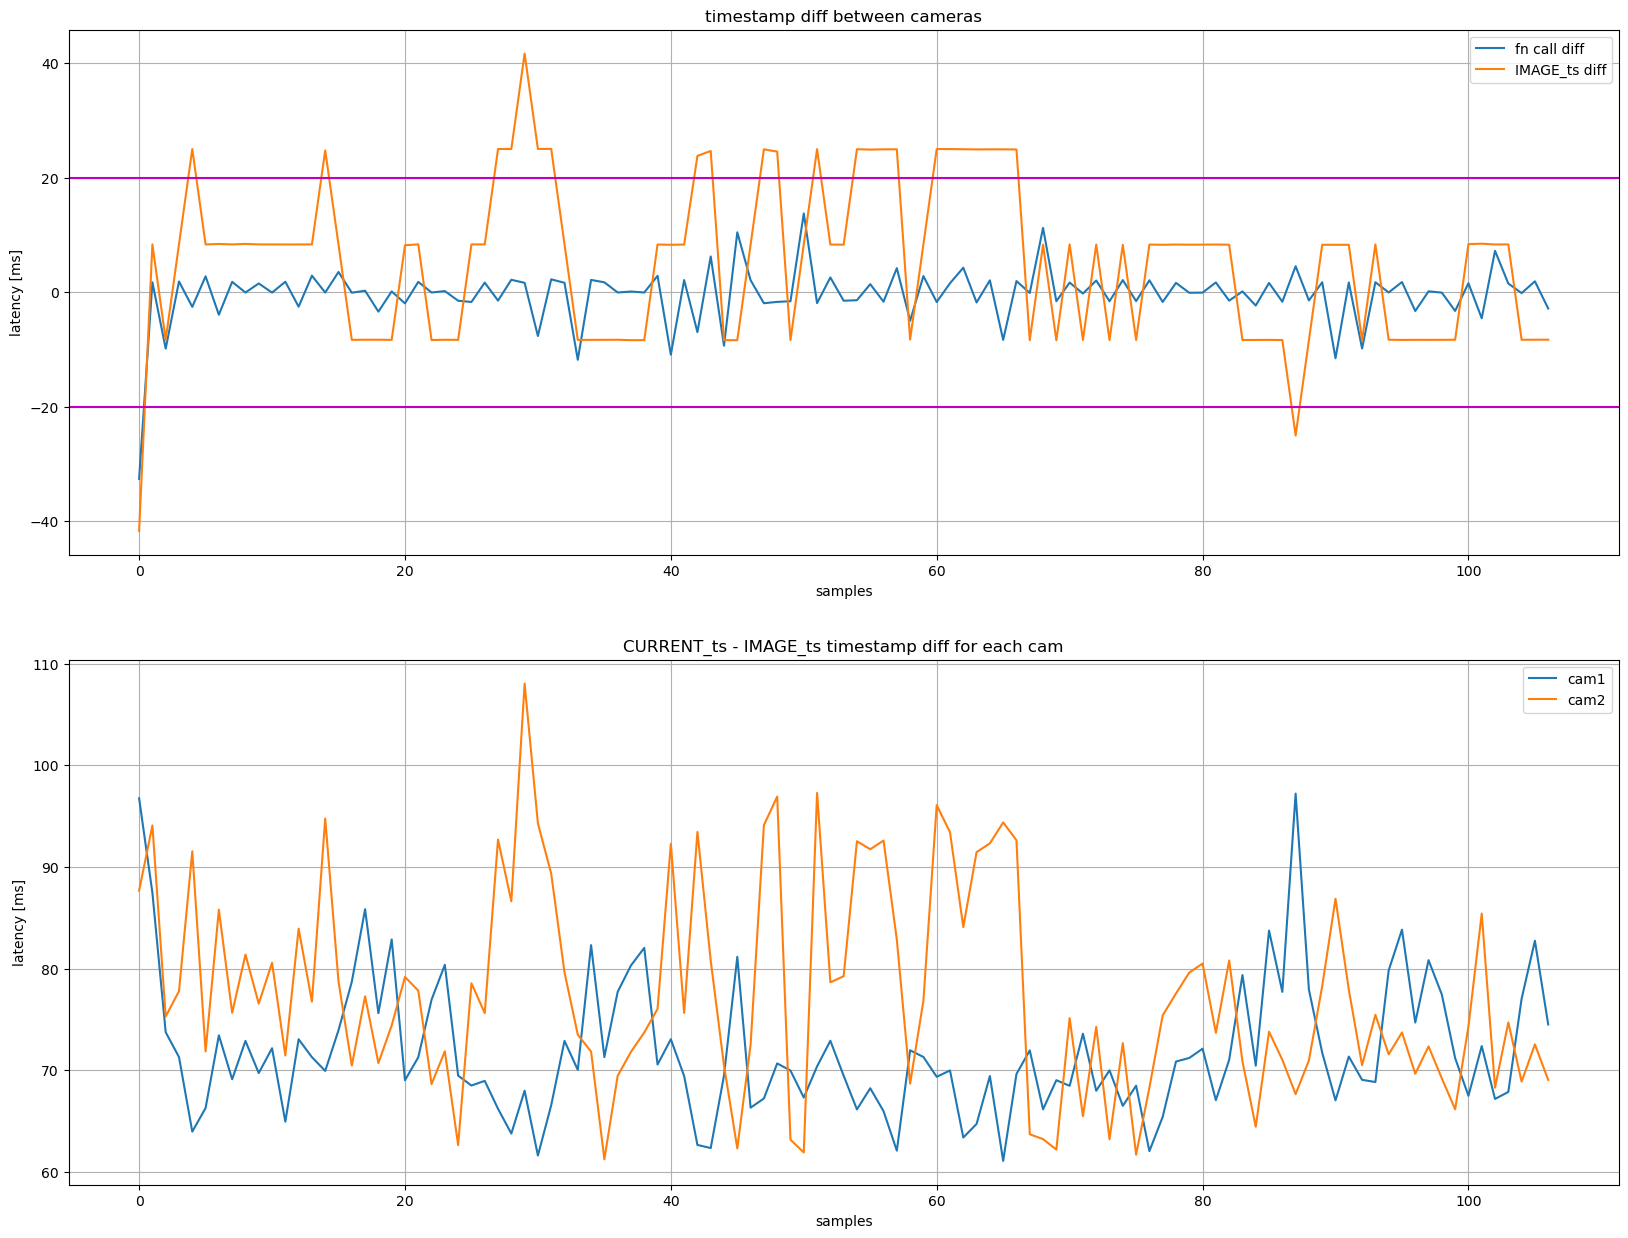

In [6]:
shorter_end_idx = min([len(cam_1_current),len(cam_2_current)])
current_vs_img_1 = cam_1_current-cam_1_img
current_vs_img_2 = cam_2_current-cam_2_img


plt.figure(figsize=(20,15))

plt.subplot(211)
plt.title('timestamp diff between cameras')
plt.plot(cam_1_current[:shorter_end_idx]-cam_2_current[:shorter_end_idx])
plt.plot(cam_1_img[:shorter_end_idx]-cam_2_img[:shorter_end_idx])
plt.axhline(y=20, color='m', linestyle='-')
plt.axhline(y=-20, color='m', linestyle='-')

plt.legend(['fn call diff','IMAGE_ts diff'])
# plt.yticks(np.linspace(-150,300,10))
plt.grid()
plt.xlabel('samples')
plt.ylabel('latency [ms]')


plt.subplot(212)
plt.title('CURRENT_ts - IMAGE_ts timestamp diff for each cam')
plt.plot(current_vs_img_1)
plt.plot(current_vs_img_2)
# plt.yticks(np.linspace(40,90,11))
plt.grid()
plt.xlabel('samples')
plt.ylabel('latency [ms]')
plt.legend(['cam1','cam2'])



In [ ]:
np.save('./latency_2_cams_1.npy',np.array(timestamps_and_images))


In [5]:
np.save('./latency_2_cams_image_reference.npy', diff_no_shift)

### Check FPS

#### Camera fps

avg fps of ZED_43957242: 31.0
avg fps of ZED_43916681: 31.63


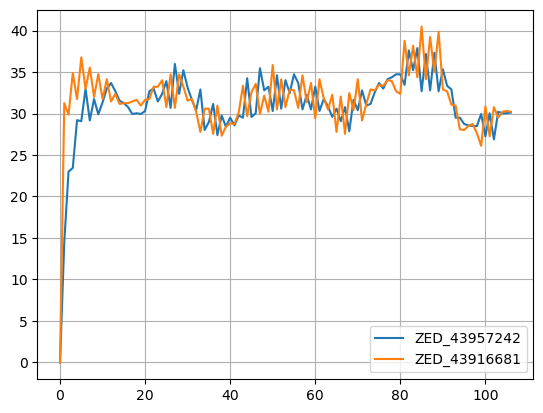

In [7]:
timestamps_and_images.keys()
plt.figure()

for camera in timestamps_and_images:
    plt.plot(timestamps_and_images[camera]['FPS'])
    # plt.axhline(round(np.mean(timestamps_and_images[camera]['FPS']),2))
    print(f'avg fps of {camera}: {round(np.mean(timestamps_and_images[camera]['FPS']),2)}')
plt.grid()
plt.legend([cam for cam in timestamps_and_images.keys()])


#### Manually

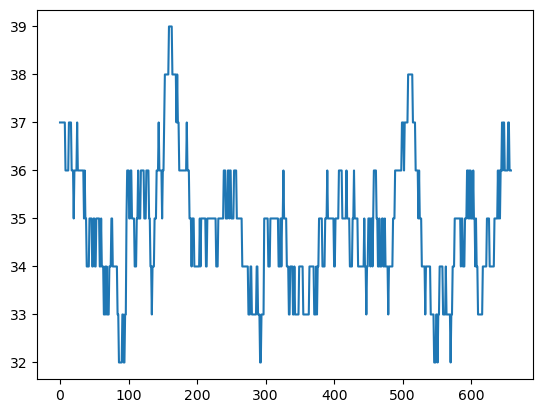

In [51]:
fps_over_time = []
half_window = 150
for i in range(half_window,len(cam_1_current)-half_window):

    diff_per_window = []
    for j in range(i-half_window,i+half_window):
        # print(j,i,abs(cam_1_current[j]-cam_1_current[i]-1000))
        diff_per_window.append([j,i,abs(cam_1_current[j]-cam_1_current[i]-1000)])
        

    diff_per_window = np.array(diff_per_window)
    one_sec_idx = np.argmin(diff_per_window,0)[2]
    fps = diff_per_window[one_sec_idx][0]-diff_per_window[one_sec_idx][1]
    fps_over_time.append(fps)


plt.plot(fps_over_time)

In [52]:
np.mean(fps_over_time), np.max(fps_over_time), np.min(fps_over_time)

(34.825493171471926, 39.0, 32.0)